<a href="https://colab.research.google.com/github/Jaslyn10/Jaslyn10-Iowa_bridges_poweredBy_Hermai/blob/main/iowa_bridges_preprocessing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iowa's Chronic *Poor* Bridges (2010–2025) — Preprocessing & EDA

**Goal.** Turn 16 separate annual U.S. DOT **National Bridge Inventory (NBI)** files for Iowa into two clean datasets that answer one question:

> *Which bridges have been rated **Poor every single year since 2010**, and whose job is it to fix them?*

**What this notebook produces**
1. `iowa_bridge_condition_history_2010_2025.csv` — every Iowa bridge × every year, labelled `Poor` / `Fair/Good` / `-` (absent). The raw longitudinal panel.
2. `iowa_chronic_poor_bridges_2010_2025.csv` — the cohort rated **Poor in all 16 years**, with traffic, age, location, and the responsible agency.


> **A word on the word "Poor."** In the NBI, *Poor* (the label that replaced *structurally deficient*) means a major component is rated ≤ 4 on a 0–9 scale and needs significant repair. It does **not** mean "about to collapse" — many Poor bridges stay open, sometimes with posted weight limits. We keep that distinction throughout.

## 1. Setup

We load the scientific-Python stack. NBI files are large (~14 MB each), and the default Excel reader (`openpyxl`) is far too slow for 16 of them, so we use the Rust-based **`calamine`** engine, which reads each file in a few seconds instead of minutes.

**Folder layout (matches the GitHub repo).** This notebook expects to sit at the repo root, next to two folders:
```
repo-root/
├── this_notebook.ipynb
├── raw data/     <- the 16 yearly NBI .xlsx files go here
└── data/         <- the two output CSVs get written here
```
- **Running locally / after `git clone`:** nothing to change — the relative paths below just work.
- **Running in Google Colab:** run the cell below first. It mounts your Google Drive and `cd`s into the project folder so the *same* relative paths (`raw data/`, `data/`) work unchanged. Edit `DRIVE_PROJECT_PATH` once to match where you put the repo/folder in your Drive.

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")


    DRIVE_PROJECT_PATH = "/content/drive/MyDrive/iowa-bridges"

    import os
    os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)
    os.chdir(DRIVE_PROJECT_PATH)
    print("Colab detected. Working directory set to:", os.getcwd())
else:
    print("Not running in Colab — using the current working directory as-is.")

Mounted at /content/drive
Colab detected. Working directory set to: /content/drive/MyDrive/iowa-bridges


In [2]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
warnings.filterwarnings("ignore")
%matplotlib inline

# Fast Excel engine (Rust). Install once if missing.
try:
    import python_calamine  # noqa
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "python-calamine"])
    import python_calamine  # noqa

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
HAZARD, STEEL = "#d0241a", "#3a4a57"

# Relative paths -> work locally, on GitHub/Binder-style clones, and in Colab (after the cell above)
UPLOADS = "raw data"
OUTPUTS = "data"
os.makedirs(OUTPUTS, exist_ok=True)
assert os.path.isdir(UPLOADS), (
    f"Couldn't find '{UPLOADS}/'. Make sure the 16 yearly .xlsx files are in a "
    f"'{UPLOADS}' folder next to this notebook (or, in Colab, that DRIVE_PROJECT_PATH "
    f"above points to the right folder)."
)
print("Ready. Reading raw files from:", os.path.abspath(UPLOADS))
print("Writing outputs to           :", os.path.abspath(OUTPUTS))

Ready. Reading raw files from: /content/drive/MyDrive/iowa-bridges/raw data
Writing outputs to           : /content/drive/MyDrive/iowa-bridges/data


## 2. The raw material: 16 annual files

Before loading anything heavy, we simply look at *what we were given*. Each year is a separate workbook; filenames even vary in capitalisation (`_iowa_` vs `_Iowa_`), so we match them with a case-insensitive glob and sort by year.

In [3]:
paths = sorted(glob.glob(f"{UPLOADS}/*_[Ii]owa_bridges.xlsx"))
files = {int(os.path.basename(p)[:4]): p for p in paths}
YEARS = sorted(files)
inv = pd.DataFrame({"year": YEARS,
                    "file": [os.path.basename(files[y]) for y in YEARS],
                    "size_MB": [round(os.path.getsize(files[y])/1e6, 1) for y in YEARS]})
print(f"{len(YEARS)} files, {YEARS[0]}–{YEARS[-1]}")
inv

16 files, 2010–2025


,year,file,size_MB
0,2010,2010_iowa_bridges.xlsx,13.8
1,2011,2011_Iowa_bridges.xlsx,13.9
2,2012,2012_Iowa_bridges.xlsx,14.0
3,2013,2013_Iowa_bridges.xlsx,14.2
4,2014,2014_Iowa_bridges.xlsx,14.2
5,2015,2015_Iowa_bridges.xlsx,13.8
6,2016,2016_Iowa_bridges.xlsx,13.9
7,2017,2017_Iowa_bridges.xlsx,14.5
8,2018,2018_Iowa_bridges.xlsx,14.8
9,2019,2019_Iowa_bridges.xlsx,13.3


## 3. Peek at one year's schema

We open just the 2010 workbook to learn three things that dictate the whole pipeline: (a) which sheet holds the data, (b) how the bridge-condition columns are encoded, and (c) whether the ready-made "Good/Fair/Poor" summary field exists this early.

In [4]:
fp10 = files[2010]
xl = pd.ExcelFile(fp10, engine="calamine")
print("sheets:", xl.sheet_names)
sheet10 = next(s for s in xl.sheet_names if s.upper().startswith("IA"))
df10 = pd.read_excel(fp10, sheet_name=sheet10, engine="calamine")
print("shape:", df10.shape)

comp_cols = ["DECK_COND_058","SUPERSTRUCTURE_COND_059","SUBSTRUCTURE_COND_060","CULVERT_COND_062"]
print("\nComponent-rating sample values (note the letter 'N' = not applicable):")
print({c: sorted(df10[c].dropna().unique().tolist())[:11] for c in comp_cols})

for c in ["BRIDGE_CONDITION","LOWEST_RATING"]:
    print(f"\n'{c}' present in 2010?", c in df10.columns)

sheets: ['IA10', 'Sheet1']
shape: (24731, 134)

Component-rating sample values (note the letter 'N' = not applicable):
{'DECK_COND_058': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'N'], 'SUPERSTRUCTURE_COND_059': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'N'], 'SUBSTRUCTURE_COND_060': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'N'], 'CULVERT_COND_062': ['0', '2', '3', '4', '5', '6', '7', '8', '9', 'N']}

'BRIDGE_CONDITION' present in 2010? False

'LOWEST_RATING' present in 2010? False


*What this tells us.* The condition of a bridge is stored as four **component ratings** (deck, superstructure, substructure, culvert) on a 0–9 scale, mixed with the letter `N` for "not applicable" (e.g. a slab bridge has no deck rating; a beam bridge has no culvert). Critically, the tidy **`BRIDGE_CONDITION`** Good/Fair/Poor field does **not** exist in 2010 — FHWA only added it around 2016. So we cannot rely on it; we must derive *Poor* ourselves from the raw components, the same way in every year.

## 4. Define one consistent "Poor", and build a slim per-year table

FHWA's official rule: a bridge is **Poor** when the **minimum** of its deck / superstructure / substructure / culvert ratings is **≤ 4** (ignoring the `N`s). We apply exactly this rule to every year — including the post-2016 files that also carry the summary field — so the definition never changes underneath us.

For each year we keep only the columns we need (identity, condition, traffic, ownership, location) and attach a single `poor` flag (`1`/`0`/`NA`). We cache each slim table so re-running is instant.

In [5]:
CACHE = "./_bridge_cache"; os.makedirs(CACHE, exist_ok=True)

# --- Item 16/17 pack coordinates DDMMSSss -> decimal degrees ---
def dms(v):
    try:
        v = int(v)
        if v <= 0: return np.nan
        d = v // 1000000; r = v % 1000000; m = r // 10000; s = (r % 10000) / 100.0
        return d + m/60 + s/3600
    except Exception:
        return np.nan

def norm_sn(x):                       # structure number -> stable integer key
    if pd.isna(x): return None
    if isinstance(x, (int, float)) and float(x).is_integer(): return int(x)
    try: return int(float(str(x).strip().strip("'")))
    except Exception: return None

def numc(df, c):                      # column -> numeric, 'N'/blank -> NaN
    return pd.to_numeric(df[c], errors="coerce") if c in df.columns else pd.Series(np.nan, index=df.index)
def col(df, c):
    return df[c] if c in df.columns else pd.Series(np.nan, index=df.index)

def build_year(year):
    cache = f"{CACHE}/slim_{year}.pkl"
    fp = files[year]
    xl = pd.ExcelFile(fp, engine="calamine")
    sheet = next((s for s in xl.sheet_names if s.upper().startswith("IA")), xl.sheet_names[0])
    raw = pd.read_excel(fp, sheet_name=sheet, engine="calamine")
    cols_present = list(raw.columns)
    if os.path.exists(cache):
        return pd.read_pickle(cache), cols_present
    d = numc(raw,"DECK_COND_058"); s_ = numc(raw,"SUPERSTRUCTURE_COND_059")
    u = numc(raw,"SUBSTRUCTURE_COND_060"); c = numc(raw,"CULVERT_COND_062")
    minr = pd.concat([d, s_, u, c], axis=1).min(axis=1)          # NaN only if all four are N/blank
    poor = pd.Series(pd.NA, index=raw.index, dtype="Int64")
    poor[minr.notna()] = (minr[minr.notna()] <= 4).astype("Int64")
    out = pd.DataFrame({
        "year": year,
        "sn": col(raw,"STRUCTURE_NUMBER_008").map(norm_sn),
        "county_code": numc(raw,"COUNTY_CODE_003"),
        "carries": col(raw,"FACILITY_CARRIED_007").astype(str).str.strip().str.strip("'").str.strip(),
        "crosses": col(raw,"FEATURES_DESC_006A").astype(str).str.strip().str.strip("'").str.strip(),
        "owner_code": numc(raw,"OWNER_022"), "maint_code": numc(raw,"MAINTENANCE_021"),
        "year_built": numc(raw,"YEAR_BUILT_027"), "year_recon": numc(raw,"YEAR_RECONSTRUCTED_106"),
        "adt": numc(raw,"ADT_029"), "adt_year": numc(raw,"YEAR_ADT_030"),
        "truck_pct": numc(raw,"PERCENT_ADT_TRUCK_109"),
        "min_rating": minr, "poor": poor,
        "lat": col(raw,"LAT_016").map(dms),
        "lon": col(raw,"LONG_017").map(dms).map(lambda x: -x if pd.notna(x) else np.nan),
        "status_code": col(raw,"OPEN_CLOSED_POSTED_041").astype(str).str.strip(),
    }).dropna(subset=["sn"]).drop_duplicates(subset=["sn"], keep="first")
    out.to_pickle(cache)
    return out, cols_present

panel, raw_columns_by_year = {}, {}
rows = []
for y in YEARS:
    slim, cols = build_year(y)
    panel[y] = slim; raw_columns_by_year[y] = cols
    rows.append((y, len(slim), int((slim.poor==1).sum()), int((slim.poor==0).sum()), int(slim.poor.isna().sum())))
summary = pd.DataFrame(rows, columns=["year","bridges","poor","fair_good","unknown"]).set_index("year")
summary

,bridges,poor,fair_good,unknown
year,,,,
2010,24698,4916,19770,12
2011,24505,4957,19521,27
2012,24465,4768,19677,20
2013,24366,4656,19690,20
2014,24268,4682,19577,9
2015,24209,4713,19489,7
2016,24151,4665,19455,31
2017,24183,4799,19374,10
2018,24091,4670,19416,5


*Why move on:* we now have 16 comparable tables sharing one honest `poor` definition. The per-year Poor counts already hint at the story (they barely move), but first we validate the assumptions behind that number with a few targeted visuals.

*Why this chart:* we claimed the tidy condition field is missing early on — let's confirm that's true across **all** years, not just 2010, before committing to the component-based definition.

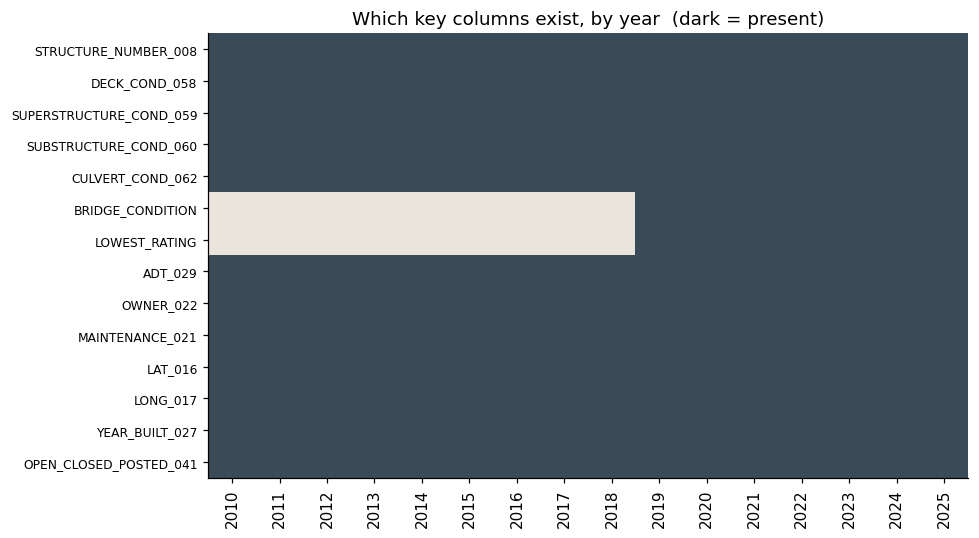

In [6]:
KEYCOLS = ["STRUCTURE_NUMBER_008","DECK_COND_058","SUPERSTRUCTURE_COND_059","SUBSTRUCTURE_COND_060",
           "CULVERT_COND_062","BRIDGE_CONDITION","LOWEST_RATING","ADT_029","OWNER_022","MAINTENANCE_021",
           "LAT_016","LONG_017","YEAR_BUILT_027","OPEN_CLOSED_POSTED_041"]
pres = pd.DataFrame({y: [c in raw_columns_by_year[y] for c in KEYCOLS] for y in YEARS}, index=KEYCOLS).astype(int)
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(pres.values, cmap=ListedColormap(["#e9e5dd", STEEL]), aspect="auto")
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS, rotation=90)
ax.set_yticks(range(len(KEYCOLS))); ax.set_yticklabels(KEYCOLS, fontsize=8)
ax.set_title("Which key columns exist, by year  (dark = present)"); ax.grid(False)
plt.tight_layout(); plt.show()

*What it shows:* the component ratings, IDs, traffic, ownership and coordinates are present **every** year, but `BRIDGE_CONDITION` and `LOWEST_RATING` blink out before ~2016. This confirms our computed-from-components Poor flag is the *only* definition that spans 2010–2025 consistently.

*Why this chart:* our whole Poor flag hinges on the `≤ 4` cutoff, so we look at where bridges actually fall on the 0–9 scale to check the threshold isn't arbitrary.

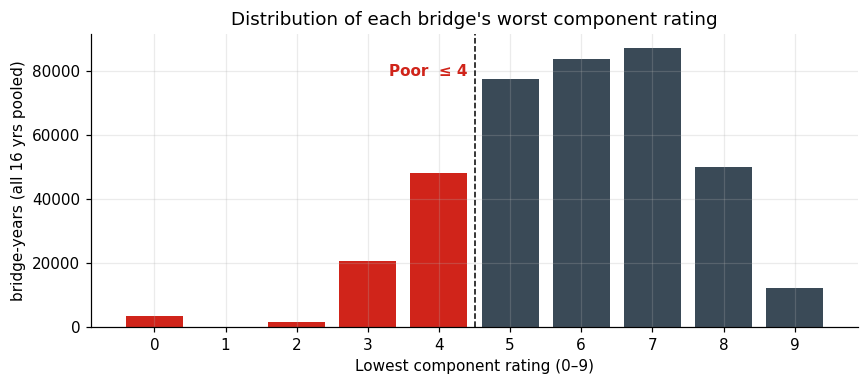

In [7]:
allmin = pd.concat([panel[y]["min_rating"] for y in YEARS]).dropna()
vc = allmin[allmin.between(0,9)].astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,3.6))
bars = ax.bar(vc.index, vc.values,
              color=[HAZARD if k<=4 else STEEL for k in vc.index])
ax.axvline(4.5, color="black", ls="--", lw=1)
ax.text(4.4, vc.max()*.9, "Poor  ≤ 4", ha="right", color=HAZARD, fontweight="bold")
ax.set_xlabel("Lowest component rating (0–9)"); ax.set_ylabel("bridge-years (all 16 yrs pooled)")
ax.set_title("Distribution of each bridge's worst component rating")
ax.set_xticks(range(0,10)); plt.tight_layout(); plt.show()

*What it shows:* the scale is roughly bell-shaped around 6–7 (typical ageing bridge), with a distinct tail at 0–4. The `≤ 4` line cleanly separates that damaged tail — a defensible, standards-based cut — so `poor = (min ≤ 4)` is sound and we can trust the yearly counts.

## 5. The join key: is `STRUCTURE_NUMBER` stable and unique?

To track a bridge *through time* we must match records across 16 files. NBI Item 8 (`STRUCTURE_NUMBER`) is the state-assigned permanent ID — the natural key — but only if it is unique within a year and stable between years. We test both by comparing the endpoints, 2010 and 2025.

In [8]:
a, b = panel[2010], panel[2025]
sa, sb = set(a.sn), set(b.sn)
print("dtype of raw key      :", pd.read_excel(files[2010], sheet_name=sheet10, engine='calamine',
        usecols=['STRUCTURE_NUMBER_008']).iloc[:,0].dtype)
print(f"2010: {len(a):,} rows / {a.sn.nunique():,} unique ids")
print(f"2025: {len(b):,} rows / {b.sn.nunique():,} unique ids")
print(f"present in BOTH 2010 & 2025 : {len(sa & sb):,}")
print(f"only 2010 (gone by 2025)    : {len(sa - sb):,}")
print(f"only 2025 (new / renumbered): {len(sb - sa):,}")

dtype of raw key      : float64
2010: 24,698 rows / 24,698 unique ids
2025: 23,688 rows / 23,688 unique ids
present in BOTH 2010 & 2025 : 19,961
only 2010 (gone by 2025)    : 4,737
only 2025 (new / renumbered): 3,727


*Why move on:* the key is numeric, essentially unique within each year, and ~19,962 bridges carry the same ID from 2010 to 2025 — plenty of continuity to build a longitudinal panel. A minority appear or vanish (bridges get built, demolished, or renumbered), which we must handle honestly rather than assume every bridge exists in every year.

*Why this chart:* before trusting a 16-year trend, we check whether the *inventory itself* is stable, and whether the number of Poor bridges is actually going down over time (i.e. is the backlog being fixed?).

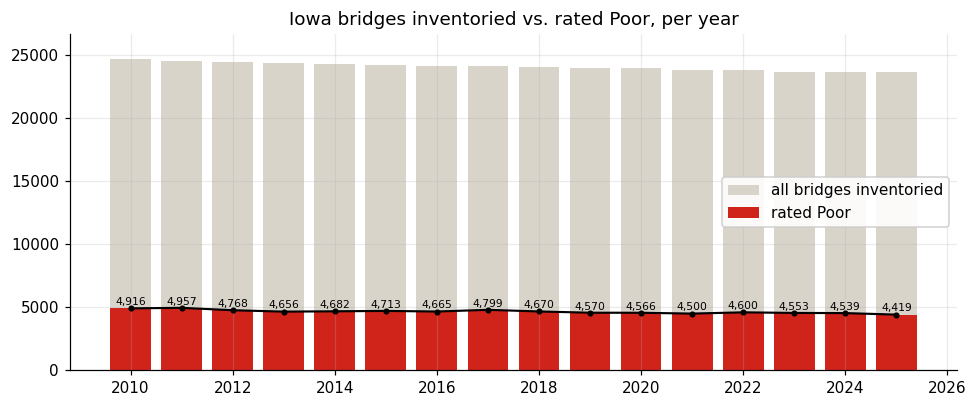

In [9]:
tot = [len(panel[y]) for y in YEARS]
poor = [int((panel[y].poor==1).sum()) for y in YEARS]
fig, ax = plt.subplots(figsize=(9,3.8))
ax.bar(YEARS, tot, color="#d9d4ca", label="all bridges inventoried")
ax.bar(YEARS, poor, color=HAZARD, label="rated Poor")
ax.plot(YEARS, poor, color="black", lw=1.4, marker="o", ms=3)
for x,p in zip(YEARS,poor): ax.text(x, p+250, f"{p:,}", ha="center", fontsize=7)
ax.set_title("Iowa bridges inventoried vs. rated Poor, per year")
ax.legend(loc="center right", framealpha=.9); ax.set_ylim(0, max(tot)*1.08)
plt.tight_layout(); plt.show()

*What it shows:* the inventory drifts down only slightly, while the Poor count sits almost flat between ~4,400 and ~4,900 — it never meaningfully improves in 16 years. A flat total, though, could hide churn (different bridges each year). That question — *are these the **same** bridges?* — is exactly what motivates building a per-bridge panel and measuring streaks.

## 6. Missing-value audit and imputation policy

Real inventories have gaps. We quantify them for the fields we depend on, then set an explicit policy. The most important decision here is a *negative* one: we will **not** impute the condition itself.

In [10]:
def miss(y):
    d = panel[y]
    return {"condition_unknown": float(d.poor.isna().mean()),
            "adt_missing": float((d.adt.isna() | (d.adt==0)).mean()),
            "coords_missing": float(d.lat.isna().mean()),
            "owner_missing": float(d.owner_code.isna().mean()),
            "yearbuilt_missing": float(d.year_built.isna().mean())}
missdf = pd.DataFrame({y: miss(y) for y in YEARS}).T
(missdf*100).round(2)

,condition_unknown,adt_missing,coords_missing,owner_missing,yearbuilt_missing
2010,0.05,0.33,0.00,0.0,0.0
2011,0.11,0.30,0.00,0.0,0.0
2012,0.08,0.26,0.00,0.0,0.0
2013,0.08,0.27,0.00,0.0,0.0
2014,0.04,0.27,0.00,0.0,0.0
2015,0.03,0.27,0.00,0.0,0.0
2016,0.13,0.30,0.00,0.0,0.0
2017,0.04,0.24,0.00,0.0,0.0
2018,0.02,0.48,0.02,0.0,0.0
2019,0.00,0.39,0.02,0.0,0.0


*Why this chart:* a heatmap makes it obvious at a glance which fields are reliable and which need a handling rule, across all years at once.

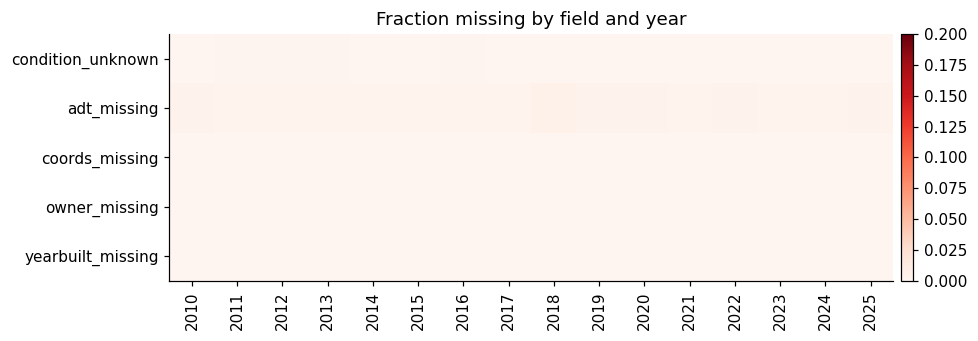

In [11]:
fig, ax = plt.subplots(figsize=(9,3.2))
im = ax.imshow(missdf.T.values, cmap="Reds", aspect="auto", vmin=0, vmax=max(0.2, missdf.values.max()))
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS, rotation=90)
ax.set_yticks(range(missdf.shape[1])); ax.set_yticklabels(missdf.columns)
ax.set_title("Fraction missing by field and year"); ax.grid(False)
fig.colorbar(im, ax=ax, fraction=.025, pad=.01); plt.tight_layout(); plt.show()

*What it shows:* **condition is essentially never missing** (our target is trustworthy), while **ADT** and occasionally coordinates have gaps. This sets the policy:
- **Condition (the target): never imputed.** Guessing "Poor" for an unseen year would fabricate the very claim we're making. Instead, a missing year simply *breaks* the "every year" test — the strict, honest choice.
- **ADT:** treated as `0` for ranking only (so a bridge is never boosted up the leaderboard by an invented traffic figure).
- **Coordinates:** a bridge with no location is kept in the data but dropped only from the *map*.

With the rules fixed, we can build the panel.

## 7. Build the condition panel (bridge × year)

We pivot the stacked years into a wide matrix — one row per bridge, one column per year — holding the `poor` flag. Missing cells (a bridge absent that year) stay as `NaN`. This matrix *is* the condition-history dataset, and the substrate for every persistence question.

In [12]:
allp = pd.concat(panel.values(), ignore_index=True)
pw = allp.pivot_table(index="sn", columns="year", values="poor", aggfunc="first").reindex(columns=YEARS)
print("panel shape (bridges × years):", pw.shape)
pw.head(4)

panel shape (bridges × years): (28467, 16)


year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
sn,,,,,,,,,,,,,,,,
40.0,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
60.0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0
71.0,0,0,<NA>,<NA>,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,0
80.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


*Why move on:* with the panel in hand, 'has this bridge always been Poor?' becomes a single row-wise test. First, a visual gut-check that persistent bridges even exist.

*Why this chart:* we sample bridges that are Poor today and lay their 16-year histories side by side — if chronic neglect is real, we'll *see* solid horizontal red streaks rather than salt-and-pepper noise.

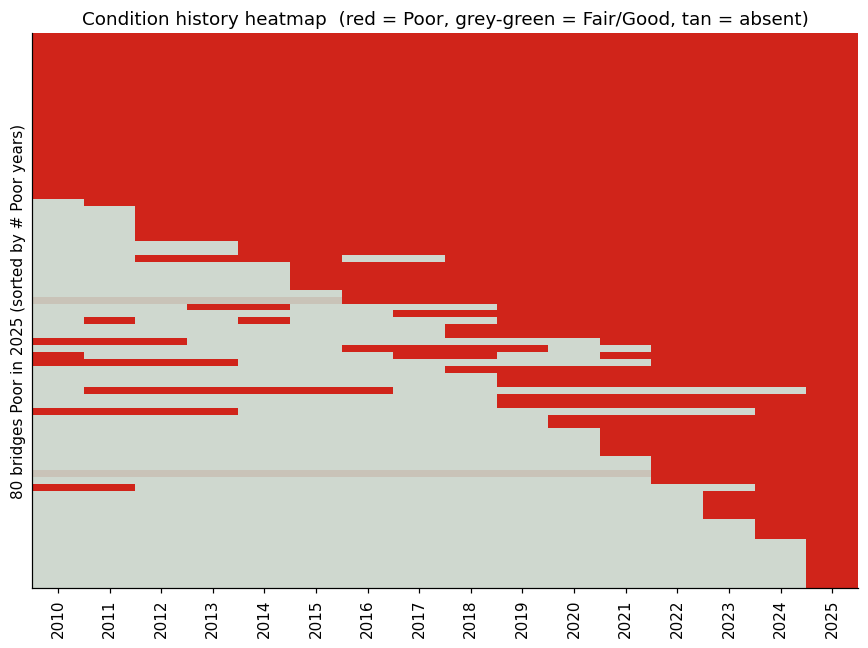

In [13]:
poor2025 = pw.index[pw[2025]==1]
rng = np.random.default_rng(7)
samp = rng.choice(poor2025, size=min(80, len(poor2025)), replace=False)
# order by how many of the 16 years are Poor, for readability
sub = pw.loc[samp].copy()
sub = sub.loc[(sub==1).sum(axis=1).sort_values(ascending=False).index]
M = sub.astype("float").fillna(-1).values  # -1 absent, 0 fair/good, 1 poor
cmap = ListedColormap(["#c9c3b8", "#cfd8cf", HAZARD])  # absent, fair/good, poor
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(M, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS, rotation=90)
ax.set_yticks([]); ax.set_ylabel(f"{len(samp)} bridges Poor in 2025 (sorted by # Poor years)")
ax.set_title("Condition history heatmap  (red = Poor, grey-green = Fair/Good, tan = absent)")
ax.grid(False); plt.tight_layout(); plt.show()

*What it shows:* the top of the panel is a wall of unbroken red — a large block of bridges Poor in *every* year — fading to mixed histories below. Chronic neglect is not a rounding artefact; it dominates. That justifies formally computing, for each bridge, its current run of consecutive Poor years.

## 8. Streaks and the strict "Poor since 2010" definition

For each bridge we count consecutive Poor years ending in 2025 (a `NaN` or a Fair/Good year breaks the run). A bridge qualifies as **chronic / "Poor since 2010"** only if it is present **and** Poor in **all 16 years** — streak = 16. This is deliberately strict: it guarantees the headline claim is literally true for every bridge in the cohort.

In [14]:
pw0 = pw.fillna(0).astype(int)          # NaN (absent) and Fair/Good both -> 0, i.e. both break a streak
arr = pw0[YEARS].to_numpy(); sns = pw.index.to_numpy()
streak = np.zeros(len(sns), dtype=int)
for i in range(len(sns)):
    c = 0
    for j in range(len(YEARS)-1, -1, -1):
        if arr[i, j] == 1: c += 1
        else: break
    streak[i] = c
st = pd.DataFrame({"sn": sns, "streak": streak})
st["poor_since"] = np.where(st.streak > 0, 2026 - st.streak, np.nan)

chronic_sns = set(st.loc[st.streak == 16, "sn"])
print(f"Bridges Poor EVERY year 2010–2025 (streak = 16): {len(chronic_sns):,}")
print(f"Poor for 10+ consecutive years              : {int((st.streak>=10).sum()):,}")
print(f"Poor in 2025 but for < 16 yrs (churn)        : {int(((st.streak>0)&(st.streak<16)).sum()):,}")

Bridges Poor EVERY year 2010–2025 (streak = 16): 1,294
Poor for 10+ consecutive years              : 2,106
Poor in 2025 but for < 16 yrs (churn)        : 3,125


*Why this chart:* the distribution of streak lengths shows whether '16 years' is a rare freak or a genuine mode — which decides whether the cohort is worth carving out.

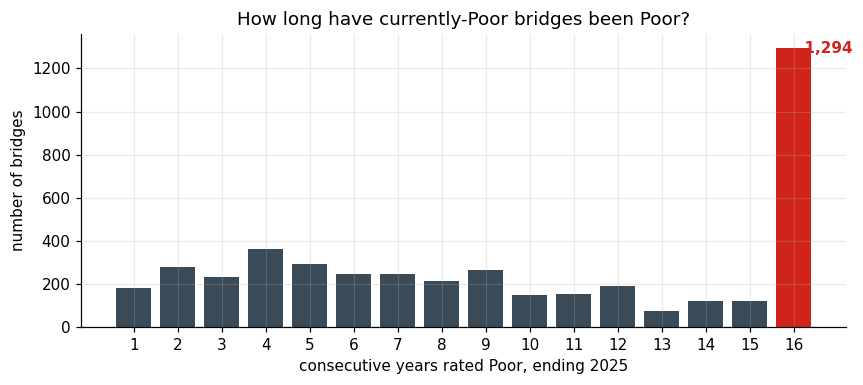

In [15]:
buck = st.loc[st.streak>0, "streak"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,3.6))
ax.bar(buck.index, buck.values, color=[HAZARD if k==16 else STEEL for k in buck.index])
ax.set_xticks(range(1,17)); ax.set_xlabel("consecutive years rated Poor, ending 2025")
ax.set_ylabel("number of bridges"); ax.set_title("How long have currently-Poor bridges been Poor?")
ax.text(16, buck.get(16,0), f"  {buck.get(16,0):,}", va="center", color=HAZARD, fontweight="bold")
plt.tight_layout(); plt.show()

*What it shows:* there's a pronounced spike at the maximum, 16 years — the single largest group. Chronic bridges aren't a tail; they're *the* dominant pattern. We extract that 16-year cohort as our second dataset.

## 9. Attach "whose job it is", and see who owns the chronic bridges

Numeric codes for owner (Item 22), maintenance responsibility (Item 21) and county (Item 3) are decoded to labels. We attach each chronic bridge's **2025** attributes (its current traffic, status and custodian) and rank by traffic.

In [16]:
OWNER={1:'Iowa DOT (State)',2:'County',3:'Town / Township',4:'City / Municipal',11:'State Park/Forest',
 21:'Other State Agency',25:'Other Local Agency',26:'Private',27:'Railroad',31:'State Toll Authority',
 32:'Local Toll Authority',60:'Other Federal',62:'Bureau of Indian Affairs',64:'US Forest Service',
 66:'National Park Service',70:'Army Corps (Civil)',80:'Unknown'}
POST={'A':'Open','B':'Open (posting recommended)','D':'Open (temporary shoring)','E':'Open (temporary)',
 'G':'Not yet open','K':'CLOSED to traffic','P':'Posted (load limit)','R':'Posted (restriction)'}
IA={1:'Adair',3:'Adams',5:'Allamakee',7:'Appanoose',9:'Audubon',11:'Benton',13:'Black Hawk',15:'Boone',17:'Bremer',19:'Buchanan',21:'Buena Vista',23:'Butler',25:'Calhoun',27:'Carroll',29:'Cass',31:'Cedar',33:'Cerro Gordo',35:'Cherokee',37:'Chickasaw',39:'Clarke',41:'Clay',43:'Clayton',45:'Clinton',47:'Crawford',49:'Dallas',51:'Davis',53:'Decatur',55:'Delaware',57:'Des Moines',59:'Dickinson',61:'Dubuque',63:'Emmet',65:'Fayette',67:'Floyd',69:'Franklin',71:'Fremont',73:'Greene',75:'Grundy',77:'Guthrie',79:'Hamilton',81:'Hancock',83:'Hardin',85:'Harrison',87:'Henry',89:'Howard',91:'Humboldt',93:'Ida',95:'Iowa',97:'Jackson',99:'Jasper',101:'Jefferson',103:'Johnson',105:'Jones',107:'Keokuk',109:'Kossuth',111:'Lee',113:'Linn',115:'Louisa',117:'Lucas',119:'Lyon',121:'Madison',123:'Mahaska',125:'Marion',127:'Marshall',129:'Mills',131:'Mitchell',133:'Monona',135:'Monroe',137:'Montgomery',139:'Muscatine',141:"O'Brien",143:'Osceola',145:'Page',147:'Palo Alto',149:'Plymouth',151:'Pocahontas',153:'Polk',155:'Pottawattamie',157:'Poweshiek',159:'Ringgold',161:'Sac',163:'Scott',165:'Shelby',167:'Sioux',169:'Story',171:'Tama',173:'Taylor',175:'Union',177:'Van Buren',179:'Wapello',181:'Warren',183:'Washington',185:'Wayne',187:'Webster',189:'Winnebago',191:'Winneshiek',193:'Woodbury',195:'Worth',197:'Wright'}
olab=lambda c:(OWNER.get(int(c),f'Owner {int(c)}') if pd.notna(c) else 'Unknown')
clab=lambda c:(IA.get(int(c),f'County {int(c)}') if pd.notna(c) else '')

meta = panel[2025].copy()
meta["owner"]=meta.owner_code.map(olab); meta["maint"]=meta.maint_code.map(olab)
meta["county"]=meta.county_code.map(clab)
meta["status"]=meta.status_code.map(lambda s: POST.get(str(s).strip(), str(s).strip()))
meta = meta.merge(st, on="sn", how="left")
meta["adt"] = meta.adt.fillna(0).astype(int)

chronic = (meta[meta.sn.isin(chronic_sns)]
           .sort_values("adt", ascending=False).reset_index(drop=True))
chronic.insert(0, "rank", chronic.index + 1)
print("chronic cohort:", len(chronic))
chronic[["rank","carries","crosses","county","owner","year_built","adt","status"]].head(8)

chronic cohort: 1294


,rank,carries,crosses,county,owner,year_built,adt,status
0,1,IA 1 NB,IOWA RIVER,Johnson,City / Municipal,1915,10950,Open
1,2,SO CENTER ST,RR AND MADISON ST,Marshall,City / Municipal,1951,9491,Posted (load limit)
2,3,6TH ST,FLOYD RIVER,Woodbury,City / Municipal,1962,8957,Open
3,4,E RIDGEWAY AVE,DRY RUN CREEK,Black Hawk,City / Municipal,1950,8392,Posted (load limit)
4,5,9TH AVE,INDIAN CREEK,Pottawattamie,City / Municipal,1930,4059,Posted (load limit)
5,6,WALNUT ST,DES MOINES RIVER,Polk,City / Municipal,1911,3844,Open
6,7,IA 141 & 175,MAPLE RIVER,Monona,Iowa DOT (State),1967,3720,Open
7,8,11TH ST,FLOYD RIVER,Woodbury,City / Municipal,1962,3523,Open


*Why this chart:* 'whose job' only lands if we know the typical custodian — a bar of owners, plus a boxplot of traffic by owner, reveals both who holds the most chronic bridges and who holds the *busy* ones.

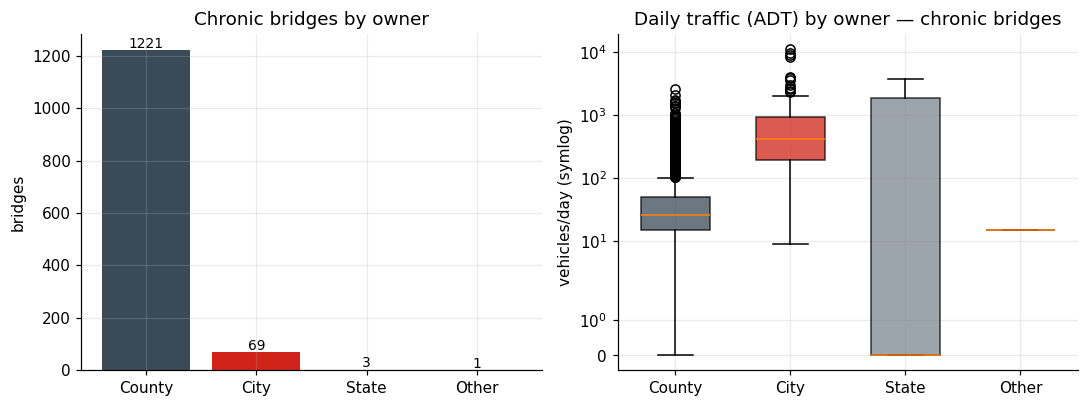

{'County': 1221, 'City': 69, 'State': 3, 'Other': 1}


In [17]:
grp = chronic.owner.map(lambda o: "County" if "County" in o else ("City" if "City" in o
                        else ("State" if "State" in o else "Other")))
order = ["County","City","State","Other"]
counts = grp.value_counts().reindex(order).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.bar(order, counts.values, color=[STEEL,HAZARD,"#7d8790","#b9b3a8"])
for i,v in enumerate(counts.values): ax1.text(i, v+8, f"{int(v)}", ha="center", fontsize=9)
ax1.set_title("Chronic bridges by owner"); ax1.set_ylabel("bridges")

data = [chronic.loc[grp==g, "adt"].values for g in order]
bp = ax2.boxplot(data, labels=order, showfliers=True, patch_artist=True, widths=.6)
for patch,c in zip(bp["boxes"], [STEEL,HAZARD,"#7d8790","#b9b3a8"]): patch.set_facecolor(c); patch.set_alpha(.75)
ax2.set_yscale("symlog"); ax2.set_title("Daily traffic (ADT) by owner — chronic bridges")
ax2.set_ylabel("vehicles/day (symlog)")
plt.tight_layout(); plt.show()
print(counts.astype(int).to_dict())

*What it shows:* the chronic list is overwhelmingly **county-owned rural spans** (~94%), the structures with the thinnest budgets — but the boxplot shows the **city**-owned handful carry far more traffic (higher median and top whisker). So the *count* story is county neglect, while the *busiest* headline bridge is municipal. Both framings are supported; we can now export with confidence.

## 10. Assemble and export the two datasets

- **Condition-history CSV:** the full panel, `Poor` / `Fair/Good` / `-`.
- **Chronic CSV:** the 16-year cohort with identity, traffic, age, custodian and coordinates.

In [18]:
# 1) Condition history (bridge × year labels)
hist = pw.astype("string").replace({"1":"Poor","0":"Fair/Good"})
hist = hist.where(pw.notna(), "-")
hist.index.name = "sn"
hist_path = f"{OUTPUTS}/iowa_bridge_condition_history_2010_2025.csv"
hist.to_csv(hist_path)

# 2) Chronic 'Poor since 2010' cohort
chronic_out = chronic[["rank","sn","carries","crosses","county","owner","maint","year_built",
                       "year_recon","adt","adt_year","truck_pct","min_rating","poor_since",
                       "streak","status","lat","lon"]].copy()
chronic_out["poor_since"] = chronic_out["poor_since"].astype("Int64")
chr_path = f"{OUTPUTS}/iowa_chronic_poor_bridges_2010_2025.csv"
chronic_out.to_csv(chr_path, index=False)

print("wrote:", os.path.basename(hist_path), hist.shape)
print("wrote:", os.path.basename(chr_path), chronic_out.shape)
chronic_out.head(5)

wrote: iowa_bridge_condition_history_2010_2025.csv (28467, 16)
wrote: iowa_chronic_poor_bridges_2010_2025.csv (1294, 18)


,rank,sn,carries,crosses,county,owner,maint,year_built,year_recon,adt,adt_year,truck_pct,min_rating,poor_since,streak,status,lat,lon
0,1,31720.0,IA 1 NB,IOWA RIVER,Johnson,City / Municipal,City / Municipal,1915,1986.0,10950,2022,4,4.0,2010,16,Open,41.657944,-91.541647
1,2,35410.0,SO CENTER ST,RR AND MADISON ST,Marshall,City / Municipal,City / Municipal,1951,0.0,9491,2022,0,3.0,2010,16,Posted (load limit),42.040642,-92.912825
2,3,10530.0,6TH ST,FLOYD RIVER,Woodbury,City / Municipal,City / Municipal,1962,1978.0,8957,2021,0,4.0,2010,16,Open,42.496475,-96.389144
3,4,11800.0,E RIDGEWAY AVE,DRY RUN CREEK,Black Hawk,City / Municipal,City / Municipal,1950,0.0,8392,2022,0,4.0,2010,16,Posted (load limit),42.469383,-92.343225
4,5,503935.0,9TH AVE,INDIAN CREEK,Pottawattamie,City / Municipal,City / Municipal,1930,0.0,4059,2022,0,3.0,2010,16,Posted (load limit),41.253444,-95.864814


## 11. Verify

We reload both files from disk and assert the properties the datasets are supposed to guarantee — the cheapest insurance against a silent pipeline bug.

In [19]:
h = pd.read_csv(hist_path, index_col=0)
c = pd.read_csv(chr_path)

assert len(c) == len(chronic_sns), "chronic row count mismatch"
assert (c.streak == 16).all(), "a chronic row is not a full 16-year streak"
assert (c.poor_since == 2010).all(), "poor_since should be 2010 for all chronic rows"
assert c.sn.is_unique, "duplicate structure numbers in chronic set"
# every chronic bridge must read 'Poor' in all 16 columns of the history panel
yrs = [str(y) for y in YEARS]
chk = h.loc[c.sn.astype(str) if h.index.dtype==object else c.sn, yrs].eq("Poor").all(axis=1)
assert chk.all(), "history panel disagrees with chronic flag"

print("All assertions passed.")
print(f"  condition history : {h.shape[0]:,} bridges × {len(yrs)} years")
print(f"  chronic cohort    : {len(c):,} bridges, all Poor 2010–2025")
top = c.iloc[0]
print(f"\nBusiest chronic bridge: {top.carries} over {top.crosses} — {top.county} County, "
      f"built {int(top.year_built)}, {int(top.adt):,} veh/day, {top.owner}.")

All assertions passed.
  condition history : 28,467 bridges × 16 years
  chronic cohort    : 1,294 bridges, all Poor 2010–2025

Busiest chronic bridge: IA 1 NB over IOWA RIVER — Johnson County, built 1915, 10,950 veh/day, City / Municipal.


## 12. Notes & caveats

- **"Poor" ≠ unsafe.** It flags a component rated ≤ 4 needing major repair; most such bridges remain open, sometimes weight-posted.
- **Strict by design.** A bridge is "Poor since 2010" only if present and Poor in **all 16** annual files. Data gaps break the streak rather than being filled in — we never impute the condition we're reporting on.
- **Traffic (ADT)** is the latest value on file per bridge and may be a few years old; missing ADT is treated as 0 for ranking only.
- **Scope is Iowa.** The same pipeline generalises to any state's NBI files, or to the full national file, by changing the inputs.
- **Source:** U.S. DOT FHWA National Bridge Inventory, Iowa, annual files 2010–2025.

**Outputs**
- `iowa_bridge_condition_history_2010_2025.csv` — every bridge's year-by-year Good/Fair/Poor record.
- `iowa_chronic_poor_bridges_2010_2025.csv` — the 1,294 bridges rated Poor every year since 2010, with the responsible agency.